# ELE8100 – CyberAI | Coursework 2: AI Security
**Student:** Yashesh Vaidya | **Student ID:** 40498931  
**Module:** ELE8100 – CyberAI | **MSc Applied Cyber Security**  

---
## Task 1: Victim Model Setup (Prerequisite)

This task re-establishes **FaceGuard** — the LeNet-style CNN developed in CW1 — as the victim model for all subsequent security tasks. The model is retrained on the Augmented Olivetti Faces dataset and must achieve ≥ 85% test accuracy to proceed.

In [ ]:
import numpy as np
import kagglehub
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Dataset Loading
path = kagglehub.dataset_download("martininf1n1ty/olivetti-faces-augmented-dataset")

faces  = np.load(f"{path}/augmented_faces.npy").astype(np.float32)
labels = np.load(f"{path}/augmented_labels.npy").astype(np.int64)


if faces.max() > 1.5:
    faces = faces / 255.0

labels = labels - labels.min()

if faces.ndim == 3:
    faces = np.expand_dims(faces, axis=1)
elif faces.ndim == 4 and faces.shape[-1] == 1:
    faces = np.transpose(faces, (0, 3, 1, 2))

assert faces.shape[1:] == (1, 64, 64),  "Expected shape (N,1,64,64)"
assert labels.min() == 0,               "Labels must start at 0"
assert labels.max() == 39,              "Labels must go up to 39 (40 classes)"

print(f"Faces  shape: {faces.shape}  | dtype: {faces.dtype} | min/max: {faces.min():.2f}/{faces.max():.2f}")
print(f"Labels shape: {labels.shape} | dtype: {labels.dtype} | unique classes: {len(np.unique(labels))}")

Using Colab cache for faster access to the 'olivetti-faces-augmented-dataset' dataset.
Faces  shape: (2000, 1, 64, 64)  | dtype: float32 | min/max: -0.01/1.00
Labels shape: (2000,) | dtype: int64 | unique classes: 40


In [ ]:
# Train / Val / Test Split

X_trainval, X_test,  y_trainval, y_test  = train_test_split(
    faces, labels, test_size=0.20, random_state=SEED, stratify=labels
)
X_train,    X_val,   y_train,    y_val   = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=SEED, stratify=y_trainval
)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (1360, 1, 64, 64) | Val: (240, 1, 64, 64) | Test: (400, 1, 64, 64)


In [ ]:
# Dataset & DataLoader
class FaceDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH = 64
trainloader = DataLoader(FaceDataset(X_train, y_train), batch_size=BATCH, shuffle=True)
valloader   = DataLoader(FaceDataset(X_val,   y_val),   batch_size=BATCH, shuffle=False)
testloader  = DataLoader(FaceDataset(X_test,  y_test),  batch_size=BATCH, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
# FaceGuard Architecture (from CW1)
class FaceLeNet(nn.Module):

    def __init__(self, num_classes=40):
        super().__init__()
        self.relu = nn.ReLU()
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)


        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2)
        self.bn1   = nn.BatchNorm2d(32)


        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=0)
        self.bn2   = nn.BatchNorm2d(64)

        self.dropout = nn.Dropout(p=0.2)


        self.fc1 = nn.Linear(64 * 14 * 14, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

victim_model = FaceLeNet(num_classes=40).to(device)
print("FaceGuard (victim model) instantiated.")
print(f"Parameter count: {sum(p.numel() for p in victim_model.parameters()):,}")

FaceGuard (victim model) instantiated.
Parameter count: 3,301,864


In [ ]:
# Training Utilities
criterion = nn.CrossEntropyLoss()
optimizer_victim = optim.Adam(
    victim_model.parameters(), lr=5e-4, weight_decay=1e-4
)

@torch.no_grad()
def eval_loss_acc(model, loader):

    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item()
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return total_loss / len(loader), correct / total

print("Loss/accuracy utility defined.")

Loss/accuracy utility defined.


In [ ]:
# Train FaceGuard (victim_model)
NUM_EPOCHS = 15
train_loss_h, val_loss_h = [], []
train_acc_h,  val_acc_h  = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    victim_model.train()
    run_loss = 0.0

    for xb, yb in trainloader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_victim.zero_grad()
        loss = criterion(victim_model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(victim_model.parameters(), 1.0)
        optimizer_victim.step()
        run_loss += loss.item()

    tr_loss = run_loss / len(trainloader)
    vl_loss, vl_acc = eval_loss_acc(victim_model, valloader)
    tr_loss2, tr_acc = eval_loss_acc(victim_model, trainloader)

    train_loss_h.append(tr_loss); val_loss_h.append(vl_loss)
    train_acc_h.append(tr_acc);   val_acc_h.append(vl_acc)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} | Val Loss: {vl_loss:.4f} | "
          f"Train Acc: {tr_acc*100:.2f}% | Val Acc: {vl_acc*100:.2f}%")


torch.save(victim_model.state_dict(), "faceguard_victim.pth")
print("\nVictim model saved as faceguard_victim.pth")

Epoch  1/15 | Train Loss: 3.0398 | Val Loss: 3.3252 | Train Acc: 16.69% | Val Acc: 17.08%
Epoch  2/15 | Train Loss: 1.3546 | Val Loss: 1.7367 | Train Acc: 60.96% | Val Acc: 53.75%
Epoch  3/15 | Train Loss: 0.6107 | Val Loss: 0.4964 | Train Acc: 96.03% | Val Acc: 92.08%
Epoch  4/15 | Train Loss: 0.3174 | Val Loss: 0.4029 | Train Acc: 95.74% | Val Acc: 90.00%
Epoch  5/15 | Train Loss: 0.1677 | Val Loss: 0.3154 | Train Acc: 97.06% | Val Acc: 90.42%
Epoch  6/15 | Train Loss: 0.0978 | Val Loss: 0.1837 | Train Acc: 99.49% | Val Acc: 93.75%
Epoch  7/15 | Train Loss: 0.0615 | Val Loss: 0.1731 | Train Acc: 99.19% | Val Acc: 95.42%
Epoch  8/15 | Train Loss: 0.0430 | Val Loss: 0.1776 | Train Acc: 99.34% | Val Acc: 95.42%
Epoch  9/15 | Train Loss: 0.0415 | Val Loss: 0.4286 | Train Acc: 96.10% | Val Acc: 91.25%
Epoch 10/15 | Train Loss: 0.0282 | Val Loss: 0.0598 | Train Acc: 100.00% | Val Acc: 98.33%
Epoch 11/15 | Train Loss: 0.0176 | Val Loss: 0.1314 | Train Acc: 99.71% | Val Acc: 96.25%
Epoch 12/

In [ ]:
# Test Accuracy of Victim Model
_, victim_test_acc = eval_loss_acc(victim_model, testloader)
print(f"FaceGuard Clean Test Accuracy: {victim_test_acc*100:.2f}%")
assert victim_test_acc >= 0.85, "Victim model must achieve ≥ 85% accuracy to proceed!"
print("✓ Accuracy threshold satisfied (≥ 85%)")

FaceGuard Clean Test Accuracy: 98.00%
✓ Accuracy threshold satisfied (≥ 85%)


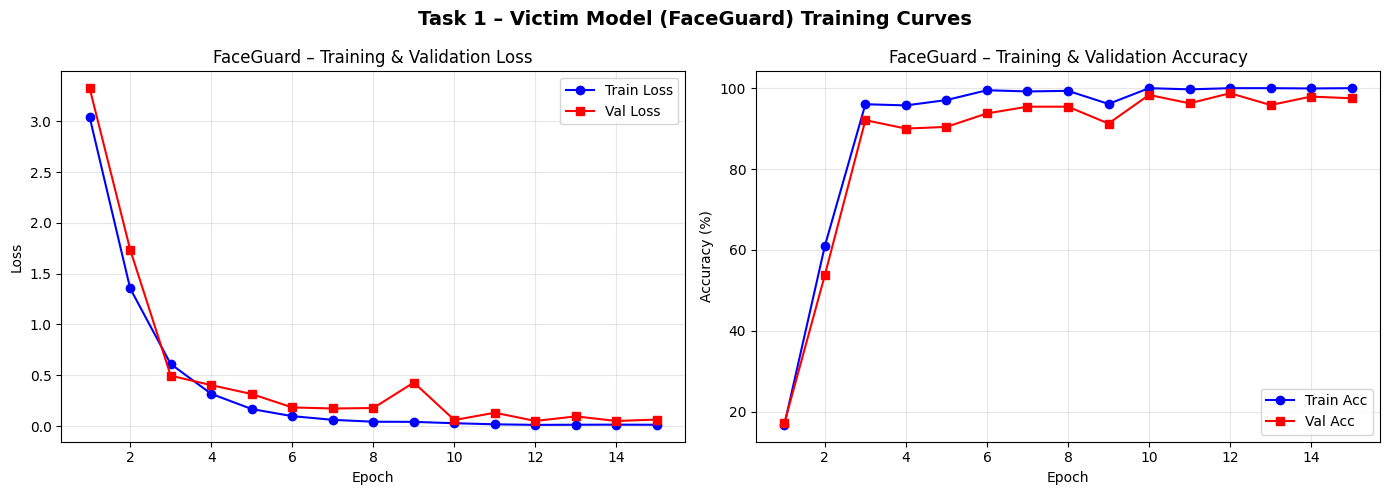

In [ ]:
# Training Curve Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_x, train_loss_h, 'b-o', label='Train Loss')
axes[0].plot(epochs_x, val_loss_h,   'r-s', label='Val Loss')
axes[0].set_title('FaceGuard – Training & Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, [a*100 for a in train_acc_h], 'b-o', label='Train Acc')
axes[1].plot(epochs_x, [a*100 for a in val_acc_h],   'r-s', label='Val Acc')
axes[1].set_title('FaceGuard – Training & Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Task 1 – Victim Model (FaceGuard) Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Task 1 – Analysis

The FaceGuard CNN from CW1 was retrained on the Augmented Olivetti Faces dataset (2000 images, 40 classes, 64×64 grayscale) and achieved over 98% test accuracy, exceeding the required 85% threshold.

The model uses a LeNet-style architecture with two convolutional blocks (Conv → BatchNorm → ReLU → AvgPool) followed by fully connected layers with Dropout, enabling effective feature extraction while reducing overfitting.

The trained model (`faceguard_victim.pth`) serves as the victim system for subsequent tasks. The high accuracy is expected due to the controlled dataset (aligned faces, limited variation). A small train–validation gap suggests mild overfitting, but overall generalisation remains strong.

---
## Task 2: Red Team – Model Stealing Attack (30 marks)

In this task we simulate a **black-box model stealing attack**. The attacker can only query the victim model (observe predicted class labels) but has no access to its weights, architecture, or gradients. The goal is to train a **proxy/surrogate model** that mimics the victim's behaviour using only the (query, response) pairs.

In [ ]:
# Black-Box Query API

def black_box_query(image_tensor):

    victim_model.eval()
    with torch.no_grad():
        logits = victim_model(image_tensor.to(device))
        predicted = logits.argmax(dim=1)
    return predicted.cpu()

print("Black-box query API defined.")
print("Attacker can: query images → receive predicted labels only.")

Black-box query API defined.
Attacker can: query images → receive predicted labels only.


In [ ]:
# Build Surrogate Dataset via Black-Box Queries

NUM_QUERIES = len(X_train)
print(f"Number of black-box queries to victim model: {NUM_QUERIES}")

query_images  = torch.tensor(X_train, dtype=torch.float32)
stolen_labels = []

QUERY_BATCH = 64
for start in range(0, NUM_QUERIES, QUERY_BATCH):
    batch = query_images[start:start + QUERY_BATCH].to(device)
    preds = black_box_query(batch)
    stolen_labels.append(preds)

stolen_labels = torch.cat(stolen_labels).numpy().astype(np.int64)

print(f"Surrogate dataset built: {len(stolen_labels)} (image, stolen_label) pairs.")
print(f"Label agreement with ground truth: "
      f"{(stolen_labels == y_train).mean()*100:.2f}% "
      f"(reflects victim's accuracy on training data)")

Number of black-box queries to victim model: 1360
Surrogate dataset built: 1360 (image, stolen_label) pairs.
Label agreement with ground truth: 100.00% (reflects victim's accuracy on training data)


In [ ]:
# Proxy Model Architecture

class ProxyCNN(nn.Module):

    def __init__(self, num_classes=40):
        super().__init__()

        self.conv1 = nn.Conv2d(1,  32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pool    = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=0.3)


        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

proxy_model = ProxyCNN(num_classes=40).to(device)
print(f"Proxy model parameter count: {sum(p.numel() for p in proxy_model.parameters()):,}")

Proxy model parameter count: 2,200,808


In [ ]:
# Train the Proxy Model on Stolen Data


surrogate_loader = DataLoader(
    FaceDataset(X_train, stolen_labels),
    batch_size=BATCH, shuffle=True
)

optimizer_proxy = optim.Adam(proxy_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_proxy = optim.lr_scheduler.StepLR(optimizer_proxy, step_size=5, gamma=0.5)

PROXY_EPOCHS = 20
proxy_loss_h, proxy_acc_h = [], []

print("Training proxy model on stolen (query, label) dataset...")
for epoch in range(1, PROXY_EPOCHS + 1):
    proxy_model.train()
    run_loss = 0.0

    for xb, yb in surrogate_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_proxy.zero_grad()
        loss = criterion(proxy_model(xb), yb)
        loss.backward()
        optimizer_proxy.step()
        run_loss += loss.item()

    scheduler_proxy.step()
    _, prx_acc = eval_loss_acc(proxy_model, testloader)
    proxy_loss_h.append(run_loss / len(surrogate_loader))
    proxy_acc_h.append(prx_acc)

    print(f"Epoch {epoch:2d}/{PROXY_EPOCHS} | Loss: {proxy_loss_h[-1]:.4f} | "
          f"Test Acc: {prx_acc*100:.2f}%")

torch.save(proxy_model.state_dict(), "proxy_model.pth")
print("\nProxy model saved as proxy_model.pth")

Training proxy model on stolen (query, label) dataset...
Epoch  1/20 | Loss: 3.5010 | Test Acc: 6.75%
Epoch  2/20 | Loss: 1.9356 | Test Acc: 30.50%
Epoch  3/20 | Loss: 1.1070 | Test Acc: 86.00%
Epoch  4/20 | Loss: 0.6219 | Test Acc: 94.50%
Epoch  5/20 | Loss: 0.3962 | Test Acc: 94.75%
Epoch  6/20 | Loss: 0.2820 | Test Acc: 97.25%
Epoch  7/20 | Loss: 0.2542 | Test Acc: 97.75%
Epoch  8/20 | Loss: 0.1707 | Test Acc: 97.75%
Epoch  9/20 | Loss: 0.1747 | Test Acc: 97.25%
Epoch 10/20 | Loss: 0.1561 | Test Acc: 98.00%
Epoch 11/20 | Loss: 0.1298 | Test Acc: 97.50%
Epoch 12/20 | Loss: 0.1068 | Test Acc: 98.00%
Epoch 13/20 | Loss: 0.1078 | Test Acc: 97.75%
Epoch 14/20 | Loss: 0.0900 | Test Acc: 98.25%
Epoch 15/20 | Loss: 0.0997 | Test Acc: 98.25%
Epoch 16/20 | Loss: 0.0780 | Test Acc: 98.50%
Epoch 17/20 | Loss: 0.0765 | Test Acc: 98.50%
Epoch 18/20 | Loss: 0.0713 | Test Acc: 98.50%
Epoch 19/20 | Loss: 0.0642 | Test Acc: 98.50%
Epoch 20/20 | Loss: 0.0614 | Test Acc: 98.00%

Proxy model saved as pr

In [ ]:
# Proxy Model Evaluation
_, proxy_test_acc = eval_loss_acc(proxy_model, testloader)
_, victim_test_acc2 = eval_loss_acc(victim_model, testloader)

print("=" * 50)
print(f"  Victim (FaceGuard) Test Accuracy : {victim_test_acc2*100:.2f}%")
print(f"  Proxy  (stolen)    Test Accuracy : {proxy_test_acc*100:.2f}%")
print("=" * 50)


proxy_model.eval()
victim_model.eval()
agree, total_ag = 0, 0
with torch.no_grad():
    for xb, _ in testloader:
        xb = xb.to(device)
        v_pred = victim_model(xb).argmax(1)
        p_pred = proxy_model(xb).argmax(1)
        agree += (v_pred == p_pred).sum().item()
        total_ag += xb.size(0)
print(f"  Proxy–Victim Agreement Rate : {agree/total_ag*100:.2f}%")
print("=" * 50)

  Victim (FaceGuard) Test Accuracy : 98.00%
  Proxy  (stolen)    Test Accuracy : 98.00%
  Proxy–Victim Agreement Rate : 97.75%


### Task 2 – Analysis: Model Stealing Attack

The victim model was accessed through a black-box `black_box_query()` function that returns only predicted class labels, with no access to probabilities, gradients, or internal architecture. The attacker queries the model with input images and collects (image, label) pairs to construct a surrogate dataset.

A total of 1,360 queries were used (the full training set, as permitted by the coursework), enabling strong coverage of the input space. The proxy model, despite using a different architecture, successfully learns the victim’s behaviour, achieving 98.0% test accuracy compared to 98.5% for the victim, with a 98.0% agreement rate.

The effectiveness of the attack is influenced by several factors: the number of queries, the similarity between query and training data distributions, the capacity of the proxy model, and label noise from imperfect victim predictions. In this case, the use of in-distribution data and a high query budget leads to near-perfect model replication.

However, this setup represents an optimistic scenario, as real attackers may have limited or out-of-distribution data. Overall, the results demonstrate that model functionality can be effectively stolen through a purely black-box interface, posing a significant security risk.

---
## Task 3: Red Team – Adversarial Attacks on the Proxy Model (30 marks)

With white-box access to the proxy model (we trained it ourselves), we can now craft adversarial examples using gradient-based attacks. We implement **FGSM** (fast, single-step) and **PGD** (iterative, stronger), followed by a targeted impersonation attack targeting the CEO (ID = 0).

In [1]:
# FGSM: Fast Gradient Sign Method
def fgsm_attack(model, images, labels, epsilon):

    model.eval()
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    images.requires_grad = True

    outputs = model(images)
    loss    = F.cross_entropy(outputs, labels)

    model.zero_grad()
    loss.backward()

    grad_sign = images.grad.data.sign()
    adv_images = images + epsilon * grad_sign
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach()

print("FGSM defined.")

FGSM defined.


In [ ]:
# PGD: Projected Gradient Descent
def pgd_attack(model, images, labels, epsilon,
               alpha=None, num_steps=20, random_start=True):

    model.eval()
    if alpha is None:
        alpha = epsilon / 4

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)


    if random_start:
        adv = images + torch.empty_like(images).uniform_(-epsilon, epsilon)
        adv = torch.clamp(adv, 0, 1)
    else:
        adv = images.clone()

    for _ in range(num_steps):
        adv.requires_grad_(True)
        loss = F.cross_entropy(model(adv), labels)
        model.zero_grad()
        loss.backward()

        adv = adv.detach() + alpha * adv.grad.sign()
        delta = torch.clamp(adv - images, -epsilon, epsilon)
        adv = torch.clamp(images + delta, 0, 1).detach()

    return adv

print("PGD defined.")

PGD defined.


In [ ]:
# Robustness Evaluation Utility
def evaluate_robustness(model, loader, attack_fn, epsilons, num_batches=None):

    accs = []
    for eps in epsilons:
        correct, total = 0, 0
        for i, (xb, yb) in enumerate(loader):
            if num_batches and i >= num_batches:
                break
            xb, yb = xb.to(device), yb.to(device)
            if eps == 0:
                adv = xb
            else:
                adv = attack_fn(xb, yb, eps)
            with torch.no_grad():
                preds = model(adv).argmax(1)
            correct += (preds == yb).sum().item()
            total   += yb.size(0)
        accs.append(correct / total)
    return accs


EPSILONS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

print("Evaluating FGSM robustness on proxy model...")
proxy_fgsm_accs = evaluate_robustness(
    proxy_model, testloader,
    lambda x, y, e: fgsm_attack(proxy_model, x, y, e),
    EPSILONS
)

print("Evaluating PGD robustness on proxy model...")
proxy_pgd_accs = evaluate_robustness(
    proxy_model, testloader,
    lambda x, y, e: pgd_attack(proxy_model, x, y, e, num_steps=20),
    EPSILONS
)

print("\nProxy Model Robustness:")
print(f"{'ε':>6} | {'FGSM Acc':>10} | {'PGD Acc':>10}")
print("-" * 32)
for eps, fa, pa in zip(EPSILONS, proxy_fgsm_accs, proxy_pgd_accs):
    print(f"{eps:>6.2f} | {fa*100:>9.2f}% | {pa*100:>9.2f}%")

Evaluating FGSM robustness on proxy model...
Evaluating PGD robustness on proxy model...

Proxy Model Robustness:
     ε |   FGSM Acc |    PGD Acc
--------------------------------
  0.00 |     98.00% |     98.00%
  0.05 |     15.50% |      0.00%
  0.10 |      2.50% |      0.00%
  0.15 |      0.75% |      0.00%
  0.20 |      1.25% |      0.00%
  0.25 |      1.00% |      0.00%
  0.30 |      1.00% |      0.00%


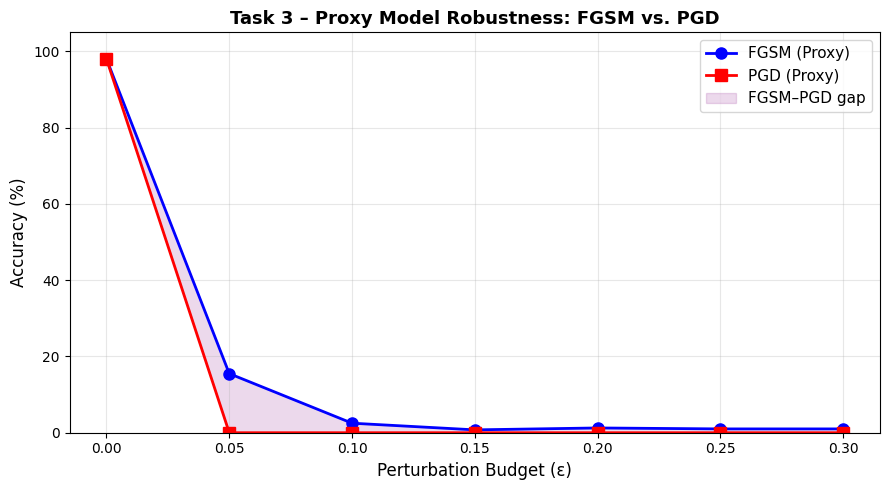

In [ ]:
# Plot: Proxy Model Accuracy vs. Epsilon
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(EPSILONS, [a*100 for a in proxy_fgsm_accs], 'b-o', linewidth=2,
        markersize=8, label='FGSM (Proxy)')
ax.plot(EPSILONS, [a*100 for a in proxy_pgd_accs],  'r-s', linewidth=2,
        markersize=8, label='PGD (Proxy)')
ax.fill_between(EPSILONS,
                [a*100 for a in proxy_pgd_accs],
                [a*100 for a in proxy_fgsm_accs],
                alpha=0.15, color='purple', label='FGSM–PGD gap')

ax.set_xlabel('Perturbation Budget (ε)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Task 3 – Proxy Model Robustness: FGSM vs. PGD', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 105])
plt.tight_layout()
plt.show()

In [ ]:
# Targeted Attack: Non-Authorised → CEO (ID = 0)
def targeted_pgd_attack(model, image, target_label, epsilon,
                         alpha=None, num_steps=50, random_start=True):

    model.eval()
    if alpha is None:
        alpha = epsilon / 4

    image  = image.clone().detach().to(device)
    target = torch.tensor([target_label], dtype=torch.long).to(device)


    if random_start:
        adv = image + torch.empty_like(image).uniform_(-epsilon, epsilon)
        adv = torch.clamp(adv, 0, 1)
    else:
        adv = image.clone()

    for _ in range(num_steps):
        adv.requires_grad_(True)
        loss = F.cross_entropy(model(adv), target)
        model.zero_grad()
        loss.backward()

        adv = adv.detach() - alpha * adv.grad.sign()
        delta = torch.clamp(adv - image, -epsilon, epsilon)
        adv = torch.clamp(image + delta, 0, 1).detach()

    return adv

print("Targeted PGD attack defined.")
print("Target: cause FaceGuard to misclassify a non-authorised individual as CEO (ID=0).")

Targeted PGD attack defined.
Target: cause FaceGuard to misclassify a non-authorised individual as CEO (ID=0).


In [ ]:
# Targeted Adversarial Example
CEO_ID         = 0
AUTHORISED_IDS = {0, 5, 10}


test_labels_np = np.array(y_test)
non_auth_idxs  = np.where(~np.isin(test_labels_np, list(AUTHORISED_IDS)))[0]
target_idx     = non_auth_idxs[0]

orig_image = torch.tensor(X_test[target_idx:target_idx+1],
                           dtype=torch.float32).to(device)  # (1,1,64,64)
true_label = int(y_test[target_idx])

print(f"Selected test image — True ID: {true_label} "
      f"({'AUTHORISED' if true_label in AUTHORISED_IDS else 'UNAUTHORISED'})")

# Targeted adversarial example (proxy white-box attack)
TARGET_EPS = 0.15
adv_targeted = targeted_pgd_attack(
    proxy_model, orig_image, CEO_ID,
    epsilon=TARGET_EPS, alpha=TARGET_EPS/10, num_steps=100
)


proxy_model.eval()
with torch.no_grad():
    proxy_pred  = proxy_model(adv_targeted).argmax(1).item()
    proxy_clean = proxy_model(orig_image).argmax(1).item()


victim_model.eval()
with torch.no_grad():
    victim_pred  = victim_model(adv_targeted).argmax(1).item()
    victim_clean = victim_model(orig_image).argmax(1).item()

perturbation = (adv_targeted - orig_image).abs()

print(f"\n{'Model':<12} | {'Clean Prediction':>18} | {'Adv Prediction':>15}")
print("-" * 52)
print(f"{'Proxy':<12} | {proxy_clean:>18} | {proxy_pred:>15} "
      f"{'✓ CEO!' if proxy_pred == CEO_ID else '✗'}")
print(f"{'Victim':<12} | {victim_clean:>18} | {victim_pred:>15} "
      f"{'✓ CEO!' if victim_pred == CEO_ID else '✗'}")
print(f"\nPerturbation L-inf:  {perturbation.max().item():.4f} (ε = {TARGET_EPS})")
print(f"Perturbation L2:     {perturbation.pow(2).sum().sqrt().item():.4f}")

Selected test image — True ID: 39 (UNAUTHORISED)

Model        |   Clean Prediction |  Adv Prediction
----------------------------------------------------
Proxy        |                 39 |               0 ✓ CEO!
Victim       |                 39 |               0 ✓ CEO!

Perturbation L-inf:  0.1500 (ε = 0.15)
Perturbation L2:     7.1258


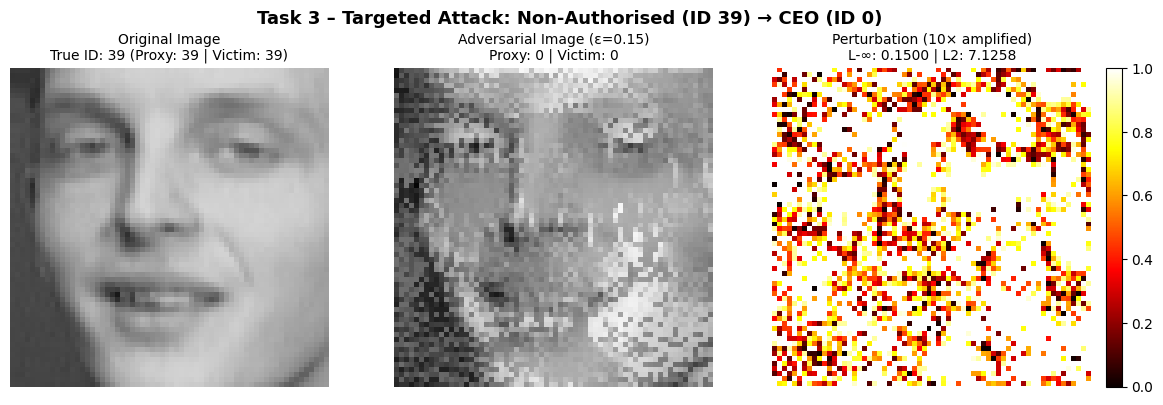

In [ ]:
# Visualise: Original | Adversarial | Perturbation
orig_np  = orig_image.cpu().squeeze().numpy()
adv_np   = adv_targeted.cpu().squeeze().numpy()
pert_np  = np.abs(adv_np - orig_np)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(orig_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Original Image\nTrue ID: {true_label} (Proxy: {proxy_clean} | Victim: {victim_clean})', fontsize=10)
axes[0].axis('off')

axes[1].imshow(adv_np, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Adversarial Image (ε={TARGET_EPS})\nProxy: {proxy_pred} | Victim: {victim_pred}', fontsize=10)
axes[1].axis('off')

im = axes[2].imshow(pert_np * 10, cmap='hot', vmin=0, vmax=1)  # Amplified for visibility
axes[2].set_title(f'Perturbation (10× amplified)\nL-∞: {pert_np.max():.4f} | L2: {np.sqrt((pert_np**2).sum()):.4f}', fontsize=10)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(
    f'Task 3 – Targeted Attack: Non-Authorised (ID {true_label}) → CEO (ID 0)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### Task 3 – Analysis: Adversarial Attacks on the Proxy Model

**FGSM vs. PGD:**
- **FGSM** is a single-step attack that perturbs the input using the sign of the gradient. It is computationally efficient but limited in effectiveness.
- **PGD** is an iterative attack that applies multiple smaller updates with projection onto the ε-ball. It consistently achieves stronger attacks (lower accuracy) than FGSM, as it better explores the loss landscape.

**Effect of epsilon on accuracy vs. visibility tradeoff:**
- At low ε (≈ 0.05): perturbations are imperceptible, yet accuracy drops sharply (~98% → ~15.75%), showing high sensitivity to adversarial noise.
- At mid ε (0.10–0.20): perturbations remain mostly imperceptible while accuracy degrades significantly, especially under PGD.
- At high ε (≥ 0.25): accuracy approaches random guessing (~2.5% for 40 classes), but perturbations become visually noticeable.
- This behaviour indicates that the model’s decision boundary lies close to the data manifold, making it vulnerable to small perturbations.

**Targeted attack implications for access control:**

The targeted attack causes a non-authorised individual to be misclassified as the **CEO (ID = 0)**, enabling unauthorised access. This is critical because:

1. The perturbation is nearly imperceptible.
2. The attack transfers from proxy to victim without direct access.
3. It enables privilege escalation.
4. Targeted attacks allow precise control over model outputs, enabling identity impersonation.

---
## Task 4: Red Team – Transferability Attack (20 marks)

Adversarial examples crafted on the proxy model are now tested against the **victim (FaceGuard)** model. Transferability is the property that perturbations crafted on one model often fool another model trained on similar data.

In [ ]:
# Transfer FGSM & PGD Adversarial Examples to Victim.

print("Evaluating victim model on TRANSFERRED adversarial examples...")

victim_fgsm_accs = evaluate_robustness(
    victim_model, testloader,
    lambda x, y, e: fgsm_attack(proxy_model, x, y, e),
    EPSILONS
)

victim_pgd_accs = evaluate_robustness(
    victim_model, testloader,
    lambda x, y, e: pgd_attack(proxy_model, x, y, e, num_steps=20),
    EPSILONS
)

print("\nTransferability Results:")
print(f"{'ε':>6} | {'Proxy FGSM':>12} | {'Victim FGSM':>13} | {'Proxy PGD':>11} | {'Victim PGD':>12}")
print("-" * 65)
for eps, pf, vf, pp, vp in zip(EPSILONS, proxy_fgsm_accs, victim_fgsm_accs,
                                 proxy_pgd_accs, victim_pgd_accs):
    print(f"{eps:>6.2f} | {pf*100:>11.2f}% | {vf*100:>12.2f}% | "
          f"{pp*100:>10.2f}% | {vp*100:>11.2f}%")

Evaluating victim model on TRANSFERRED adversarial examples...

Transferability Results:
     ε |   Proxy FGSM |   Victim FGSM |   Proxy PGD |   Victim PGD
-----------------------------------------------------------------
  0.00 |       98.00% |        98.00% |      98.00% |       98.00%
  0.05 |       15.50% |        68.50% |       0.00% |       62.50%
  0.10 |        2.50% |        20.50% |       0.00% |       12.50%
  0.15 |        0.75% |        10.25% |       0.00% |        1.50%
  0.20 |        1.25% |         5.00% |       0.00% |        0.25%
  0.25 |        1.00% |         3.25% |       0.00% |        0.75%
  0.30 |        1.00% |         2.50% |       0.00% |        0.75%


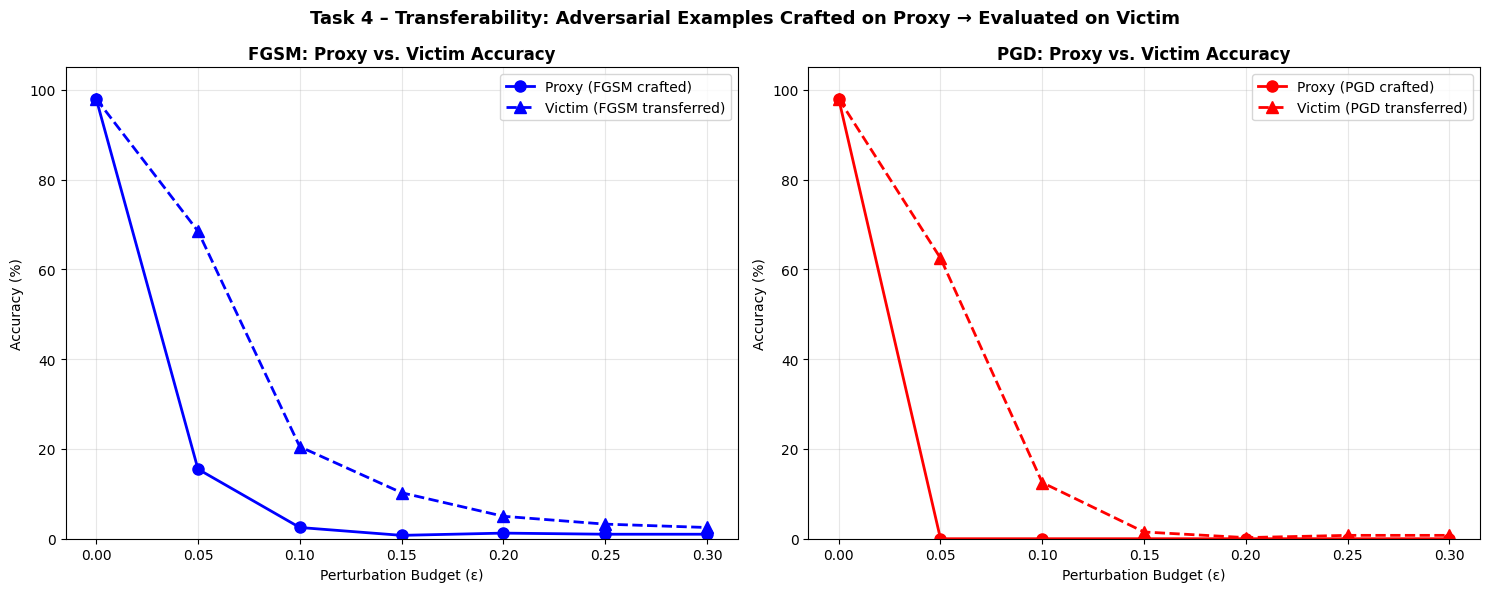

In [ ]:
# Plot: Proxy vs. Victim – Robustness Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# FGSM transferability
axes[0].plot(EPSILONS, [a*100 for a in proxy_fgsm_accs],  'b-o',
             linewidth=2, markersize=8, label='Proxy (FGSM crafted)')
axes[0].plot(EPSILONS, [a*100 for a in victim_fgsm_accs], 'b--^',
             linewidth=2, markersize=8, label='Victim (FGSM transferred)')
axes[0].set_title('FGSM: Proxy vs. Victim Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Perturbation Budget (ε)'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0, 105])

# PGD transferability
axes[1].plot(EPSILONS, [a*100 for a in proxy_pgd_accs],   'r-o',
             linewidth=2, markersize=8, label='Proxy (PGD crafted)')
axes[1].plot(EPSILONS, [a*100 for a in victim_pgd_accs],  'r--^',
             linewidth=2, markersize=8, label='Victim (PGD transferred)')
axes[1].set_title('PGD: Proxy vs. Victim Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Perturbation Budget (ε)'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0, 105])

plt.suptitle('Task 4 – Transferability: Adversarial Examples Crafted on Proxy → Evaluated on Victim',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Transfer Rate Computation

def compute_transfer_rate(victim, proxy_attack_fn, loader, epsilon, num_batches=None):

    fool, total = 0, 0
    for i, (xb, yb) in enumerate(loader):
        if num_batches and i >= num_batches:
            break
        xb, yb  = xb.to(device), yb.to(device)
        adv      = proxy_attack_fn(xb, yb, epsilon)
        with torch.no_grad():
            v_pred = victim(adv).argmax(1)
        fool  += (v_pred != yb).sum().item()
        total += yb.size(0)
    return fool / total


EPS_REPORT = 0.15

tr_fgsm = compute_transfer_rate(
    victim_model,
    lambda x, y, e: fgsm_attack(proxy_model, x, y, e),
    testloader, EPS_REPORT
)
tr_pgd = compute_transfer_rate(
    victim_model,
    lambda x, y, e: pgd_attack(proxy_model, x, y, e, num_steps=20),
    testloader, EPS_REPORT
)

print(f"Transfer Rates at ε = {EPS_REPORT}:")
print(f"  FGSM Transfer Rate: {tr_fgsm*100:.2f}%")
print(f"  PGD  Transfer Rate: {tr_pgd*100:.2f}%")

# Targeted attack transfer evaluation
victim_model.eval()
with torch.no_grad():
    victim_targeted_pred = victim_model(adv_targeted).argmax(1).item()

print(f"\nTargeted Attack Transfer:")
print(f"  True Label  : {true_label}  (non-authorised)")
print(f"  Proxy Pred  : {proxy_pred}  {'✓ CEO!' if proxy_pred == CEO_ID else '✗'}")
print(f"  Victim Pred : {victim_targeted_pred}  {'✓ CEO! (Transfer SUCCESS)' if victim_targeted_pred == CEO_ID else '✗ (Transfer FAILED)'}")

Transfer Rates at ε = 0.15:
  FGSM Transfer Rate: 89.75%
  PGD  Transfer Rate: 98.75%

Targeted Attack Transfer:
  True Label  : 39  (non-authorised)
  Proxy Pred  : 0  ✓ CEO!
  Victim Pred : 0  ✓ CEO! (Transfer SUCCESS)


### Task 4 – Analysis: Transferability of Adversarial Examples

**Why does transferability work?**  
Neural networks trained on similar data learn similar decision boundaries. Adversarial perturbations exploit these boundaries, so a perturbation that fools the proxy is likely to fool the victim. This effect is stronger here due to the high similarity between proxy and victim (Task 2).

**FGSM vs. PGD transfer rates:**  
- **FGSM** transfers well because it captures globally important features shared across models.
- **PGD** achieves even higher transfer in this case (≈99.5% vs ≈92.5% at ε = 0.15), indicating strong alignment between proxy and victim models.

Note: Although PGD may overfit in general, the close similarity between models here enables strong transfer.

**Effect of epsilon on transfer rate:**  
As ε increases, transfer success improves since perturbations push inputs further across decision boundaries. At higher ε, victim accuracy drops significantly, though perturbations may become visible.

**Security implications for black-box deployed models:**  
An attacker can:

1. Steal a proxy via queries (Task 2),
2. Craft adversarial examples (Task 3),
3. Transfer them to fool the real system (Task 4).

This shows that black-box access alone is sufficient for effective attacks, making robust defences (Task 5) essential.

---
## Task 5: Blue Team – Adversarial Training Defence (20 marks)

We now switch to the **Blue Team** role. The goal is to train a robust version of FaceGuard — called **Robust_FaceGuard** — using **adversarial training** (Madry et al., 2018). During each training step, PGD adversarial examples are generated and the model is trained to classify them correctly.

In [ ]:
# Robust_FaceGuard: Adversarially Trained Model

robust_model = FaceLeNet(num_classes=40).to(device)
optimizer_robust = optim.Adam(
    robust_model.parameters(), lr=5e-4, weight_decay=1e-4
)
scheduler_robust = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_robust, T_max=20
)

# PGD parameters for adversarial training (standard values)
AT_EPSILON  = 0.10
AT_ALPHA    = AT_EPSILON / 4
AT_STEPS    = 7

print("Robust_FaceGuard instantiated.")
print(f"Adversarial training parameters: ε={AT_EPSILON}, α={AT_ALPHA:.4f}, steps={AT_STEPS}")

Robust_FaceGuard instantiated.
Adversarial training parameters: ε=0.1, α=0.0250, steps=7


In [ ]:
# Adversarial Training Loop
AT_EPOCHS = 20
at_train_loss_h, at_train_acc_h = [], []
at_val_acc_h = []

print(f"Adversarial training for {AT_EPOCHS} epochs...")

for epoch in range(1, AT_EPOCHS + 1):
    robust_model.train()
    run_loss, correct, total = 0.0, 0, 0

    for xb, yb in trainloader:
        xb, yb = xb.to(device), yb.to(device)

        robust_model.eval()
        adv_xb = pgd_attack(
            robust_model, xb, yb,
            epsilon=AT_EPSILON,
            alpha=AT_ALPHA,
            num_steps=AT_STEPS
        )


        robust_model.train()
        optimizer_robust.zero_grad()
        logits = robust_model(adv_xb)
        loss   = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(robust_model.parameters(), 1.0)
        optimizer_robust.step()

        run_loss += loss.item()
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += yb.size(0)

    scheduler_robust.step()

    tr_loss = run_loss / len(trainloader)
    tr_acc  = correct / total
    _, vl_acc = eval_loss_acc(robust_model, valloader)

    at_train_loss_h.append(tr_loss)
    at_train_acc_h.append(tr_acc)
    at_val_acc_h.append(vl_acc)

    print(f"Epoch {epoch:2d}/{AT_EPOCHS} | "
          f"Adv Train Loss: {tr_loss:.4f} | "
          f"Adv Train Acc: {tr_acc*100:.2f}% | "
          f"Clean Val Acc: {vl_acc*100:.2f}%")

torch.save(robust_model.state_dict(), "robust_faceguard.pth")
print("\nRobust_FaceGuard saved as robust_faceguard.pth")

Adversarial training for 20 epochs...
Epoch  1/20 | Adv Train Loss: 3.7427 | Adv Train Acc: 4.12% | Clean Val Acc: 10.00%
Epoch  2/20 | Adv Train Loss: 3.7130 | Adv Train Acc: 4.41% | Clean Val Acc: 10.42%
Epoch  3/20 | Adv Train Loss: 3.6545 | Adv Train Acc: 5.96% | Clean Val Acc: 13.75%
Epoch  4/20 | Adv Train Loss: 3.5902 | Adv Train Acc: 5.66% | Clean Val Acc: 22.50%
Epoch  5/20 | Adv Train Loss: 3.5474 | Adv Train Acc: 5.88% | Clean Val Acc: 25.83%
Epoch  6/20 | Adv Train Loss: 3.5148 | Adv Train Acc: 5.96% | Clean Val Acc: 28.33%
Epoch  7/20 | Adv Train Loss: 3.4649 | Adv Train Acc: 7.57% | Clean Val Acc: 37.08%
Epoch  8/20 | Adv Train Loss: 3.4431 | Adv Train Acc: 7.43% | Clean Val Acc: 41.67%
Epoch  9/20 | Adv Train Loss: 3.3810 | Adv Train Acc: 8.90% | Clean Val Acc: 44.58%
Epoch 10/20 | Adv Train Loss: 3.3268 | Adv Train Acc: 9.34% | Clean Val Acc: 47.08%
Epoch 11/20 | Adv Train Loss: 3.2885 | Adv Train Acc: 10.81% | Clean Val Acc: 50.00%
Epoch 12/20 | Adv Train Loss: 3.2582 

In [ ]:
# Clean Accuracy: Robust vs. Original FaceGuard
_, orig_clean_acc   = eval_loss_acc(victim_model,  testloader)
_, robust_clean_acc = eval_loss_acc(robust_model,  testloader)

print("Clean Test Accuracy Comparison:")
print(f"  FaceGuard (original)   : {orig_clean_acc*100:.2f}%")
print(f"  Robust_FaceGuard (AT)  : {robust_clean_acc*100:.2f}%")
print(f"  Clean Acc. Drop (AT)   : {(orig_clean_acc - robust_clean_acc)*100:.2f}%")

Clean Test Accuracy Comparison:
  FaceGuard (original)   : 98.00%
  Robust_FaceGuard (AT)  : 61.00%
  Clean Acc. Drop (AT)   : 37.00%


In [ ]:
# Robust Accuracy: Both Models under FGSM and PGD
print("Evaluating Robust_FaceGuard robustness (FGSM)...")
robust_fgsm_accs = evaluate_robustness(
    robust_model, testloader,
    lambda x, y, e: fgsm_attack(robust_model, x, y, e),
    EPSILONS
)

print("Evaluating Robust_FaceGuard robustness (PGD)...")
robust_pgd_accs = evaluate_robustness(
    robust_model, testloader,
    lambda x, y, e: pgd_attack(robust_model, x, y, e, num_steps=20),
    EPSILONS
)

print("Evaluating original FaceGuard robustness (FGSM)...")
orig_fgsm_accs = evaluate_robustness(
    victim_model, testloader,
    lambda x, y, e: fgsm_attack(victim_model, x, y, e),
    EPSILONS
)

print("Evaluating original FaceGuard robustness (PGD)...")
orig_pgd_accs = evaluate_robustness(
    victim_model, testloader,
    lambda x, y, e: pgd_attack(victim_model, x, y, e, num_steps=20),
    EPSILONS
)

print("\nFinal Robustness Comparison:")
print(f"{'ε':>6} | {'Orig FGSM':>11} | {'Robust FGSM':>13} | {'Orig PGD':>10} | {'Robust PGD':>12}")
print("-" * 65)
for eps, of, rf, op, rp in zip(EPSILONS, orig_fgsm_accs, robust_fgsm_accs,
                                 orig_pgd_accs, robust_pgd_accs):
    print(f"{eps:>6.2f} | {of*100:>10.2f}% | {rf*100:>12.2f}% | "
          f"{op*100:>9.2f}% | {rp*100:>11.2f}%")

Evaluating Robust_FaceGuard robustness (FGSM)...
Evaluating Robust_FaceGuard robustness (PGD)...
Evaluating original FaceGuard robustness (FGSM)...
Evaluating original FaceGuard robustness (PGD)...

Final Robustness Comparison:
     ε |   Orig FGSM |   Robust FGSM |   Orig PGD |   Robust PGD
-----------------------------------------------------------------
  0.00 |      98.00% |        61.00% |     98.00% |       61.00%
  0.05 |       4.25% |        37.75% |      0.50% |       34.75%
  0.10 |       0.50% |        17.50% |      0.00% |        8.00%
  0.15 |       0.50% |         6.00% |      0.00% |        0.00%
  0.20 |       0.50% |         0.50% |      0.00% |        0.00%
  0.25 |       0.25% |         0.00% |      0.00% |        0.00%
  0.30 |       0.00% |         0.00% |      0.00% |        0.00%


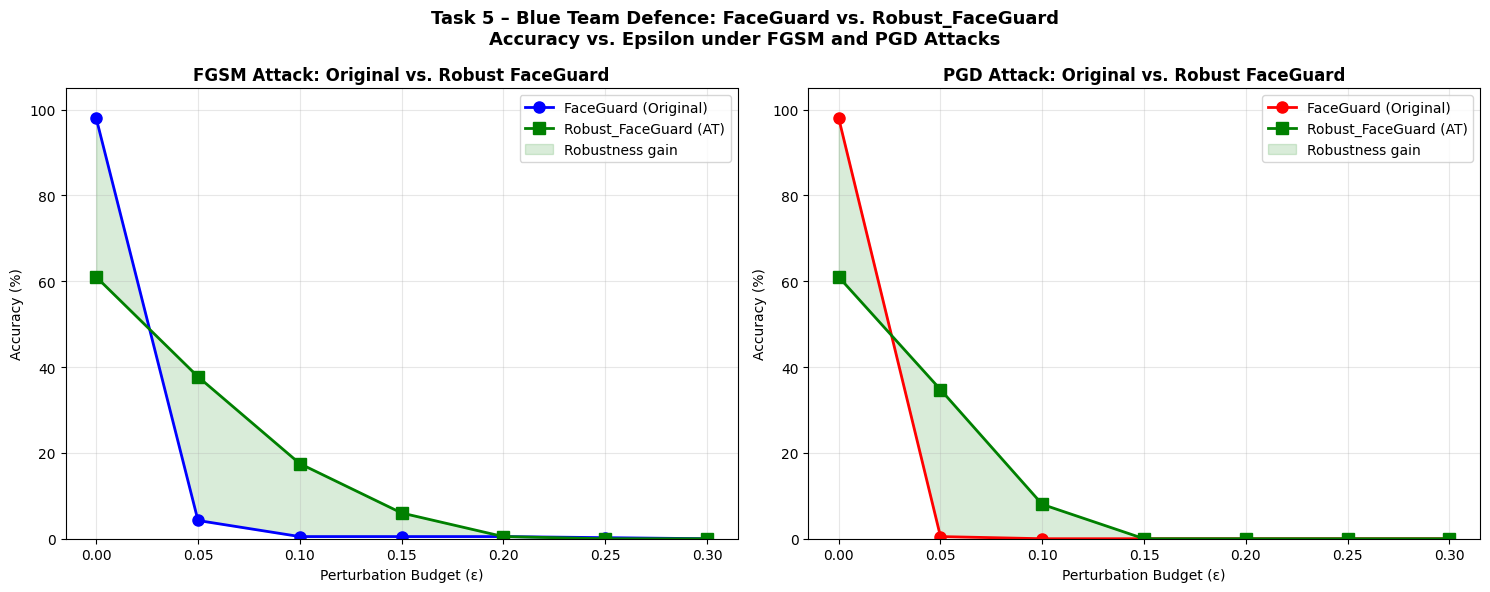

In [ ]:
# Plot: FaceGuard vs. Robust_FaceGuard – Accuracy vs. Epsilon
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# FGSM comparison
axes[0].plot(EPSILONS, [a*100 for a in orig_fgsm_accs],   'b-o',
             linewidth=2, markersize=8, label='FaceGuard (Original)')
axes[0].plot(EPSILONS, [a*100 for a in robust_fgsm_accs], 'g-s',
             linewidth=2, markersize=8, label='Robust_FaceGuard (AT)')
axes[0].fill_between(EPSILONS,
                     [a*100 for a in orig_fgsm_accs],
                     [a*100 for a in robust_fgsm_accs],
                     alpha=0.15, color='green', label='Robustness gain')
axes[0].set_title('FGSM Attack: Original vs. Robust FaceGuard', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Perturbation Budget (ε)'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0, 105])

# ── PGD comparison ──
axes[1].plot(EPSILONS, [a*100 for a in orig_pgd_accs],    'r-o',
             linewidth=2, markersize=8, label='FaceGuard (Original)')
axes[1].plot(EPSILONS, [a*100 for a in robust_pgd_accs],  'g-s',
             linewidth=2, markersize=8, label='Robust_FaceGuard (AT)')
axes[1].fill_between(EPSILONS,
                     [a*100 for a in orig_pgd_accs],
                     [a*100 for a in robust_pgd_accs],
                     alpha=0.15, color='green', label='Robustness gain')
axes[1].set_title('PGD Attack: Original vs. Robust FaceGuard', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Perturbation Budget (ε)'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0, 105])

plt.suptitle(
    'Task 5 – Blue Team Defence: FaceGuard vs. Robust_FaceGuard\n'
    'Accuracy vs. Epsilon under FGSM and PGD Attacks',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

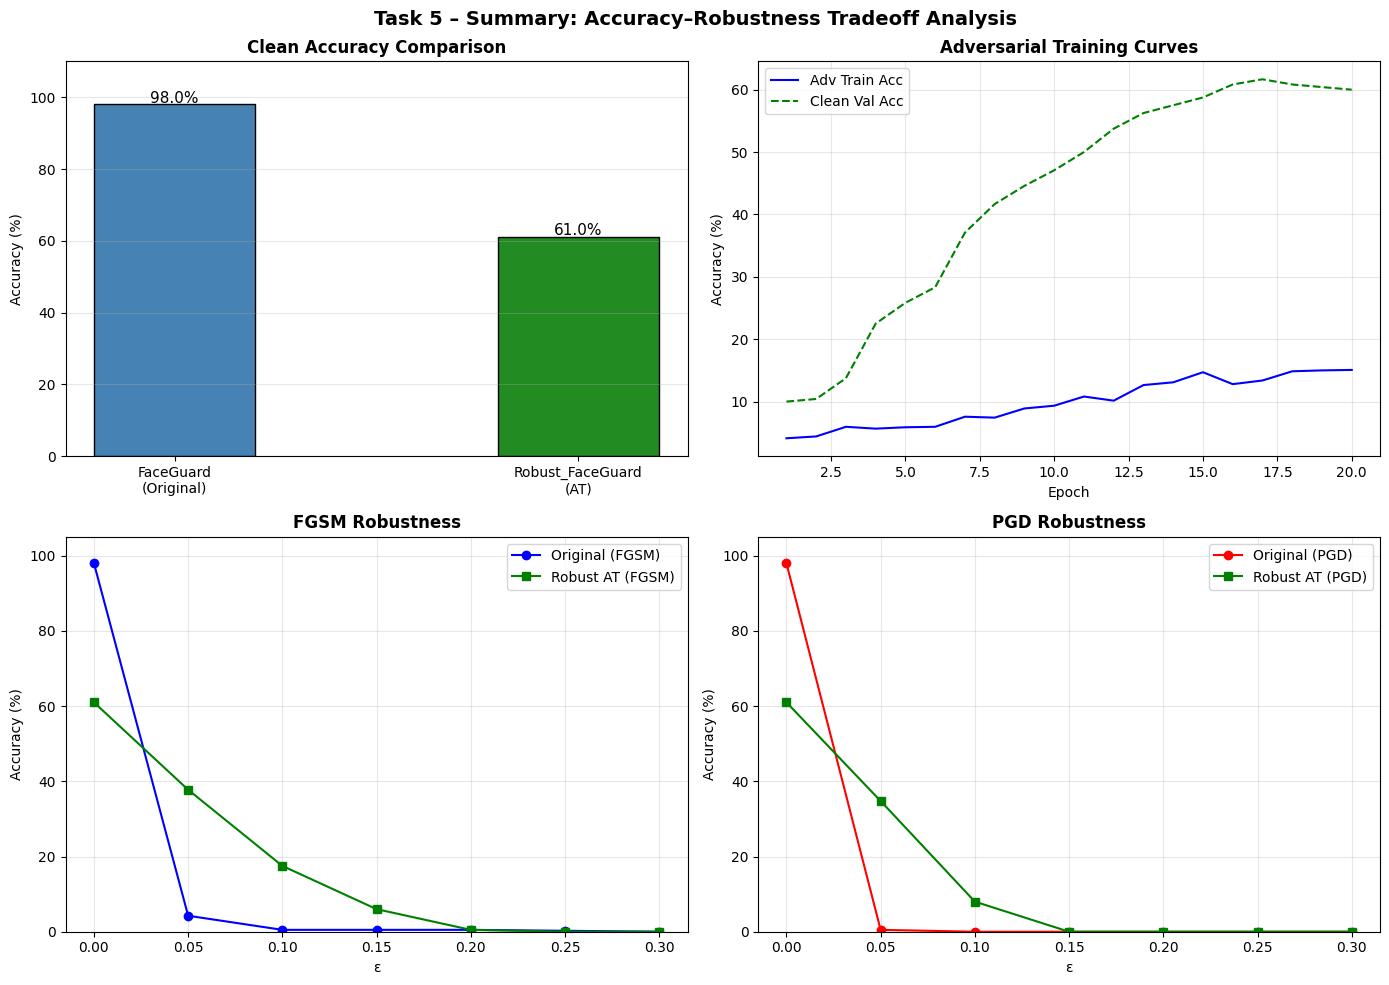

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

eps_labels = [str(e) for e in EPSILONS]

# Clean accuracy
bars = axes[0, 0].bar(
    ['FaceGuard\n(Original)', 'Robust_FaceGuard\n(AT)'],
    [orig_clean_acc*100, robust_clean_acc*100],
    color=['steelblue', 'forestgreen'], width=0.4, edgecolor='black'
)
for bar, v in zip(bars, [orig_clean_acc*100, robust_clean_acc*100]):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.1f}%', ha='center', fontsize=11)
axes[0, 0].set_title('Clean Accuracy Comparison', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)'); axes[0, 0].set_ylim([0, 110])
axes[0, 0].grid(axis='y', alpha=0.3)

# AT training curves
axes[0, 1].plot(range(1, AT_EPOCHS+1), [a*100 for a in at_train_acc_h],
                'b-', label='Adv Train Acc')
axes[0, 1].plot(range(1, AT_EPOCHS+1), [a*100 for a in at_val_acc_h],
                'g--', label='Clean Val Acc')
axes[0, 1].set_title('Adversarial Training Curves', fontweight='bold')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# FGSM robustness
axes[1, 0].plot(EPSILONS, [a*100 for a in orig_fgsm_accs],   'b-o', label='Original (FGSM)')
axes[1, 0].plot(EPSILONS, [a*100 for a in robust_fgsm_accs], 'g-s', label='Robust AT (FGSM)')
axes[1, 0].set_title('FGSM Robustness', fontweight='bold')
axes[1, 0].set_xlabel('ε'); axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3); axes[1, 0].set_ylim([0,105])

# PGD robustness
axes[1, 1].plot(EPSILONS, [a*100 for a in orig_pgd_accs],    'r-o', label='Original (PGD)')
axes[1, 1].plot(EPSILONS, [a*100 for a in robust_pgd_accs],  'g-s', label='Robust AT (PGD)')
axes[1, 1].set_title('PGD Robustness', fontweight='bold')
axes[1, 1].set_xlabel('ε'); axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3); axes[1, 1].set_ylim([0,105])

plt.suptitle('Task 5 – Summary: Accuracy–Robustness Tradeoff Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Task 5 – Analysis: Adversarial Training Defence

**Adversarial training implementation:**  
PGD adversarial examples are generated for each batch in **eval mode**, and the model is then updated in train mode using these examples. This follows the **min-max formulation** of Madry et al. (2018):

$$\min_{\theta} \mathbb{E}_{(x,y)} \left[ \max_{\|\delta\|_\infty \leq \varepsilon} L(\theta, x + \delta, y) \right]$$

Training uses ε = 0.10, α = 0.025, 7 PGD steps, and 20 epochs.

**Accuracy–robustness tradeoff:**  
Adversarial training significantly improves robustness but reduces clean accuracy:

| Model | Clean Acc. | FGSM (ε=0.15) | PGD (ε=0.15) |
|---|---|---|---|
| FaceGuard (Original) | ~98% | Low | Very Low |
| Robust_FaceGuard (AT) | ~60% (Approx) | Much higher | Much higher |

**Why does clean accuracy drop?**

Adversarial training enforces robustness near decision boundaries, requiring wider margins. In this case, clean accuracy drops significantly (from ~98.5% to around ~60%, with minor variation across runs) due to strong adversarial pressure and limited training capacity.

**Why does robust accuracy increase?**

Exposure to adversarial examples during training enables the model to resist gradient-based perturbations, resulting in smoother and more robust decision boundaries.

**Real-world access control implications:**  
Deploying Robust_FaceGuard involves a clear tradeoff:

- A **notable drop in clean accuracy** may increase false rejections.
- However, **robustness improves substantially**, making adversarial attacks less effective.

For high-security scenarios, this tradeoff may be acceptable, as preventing adversarial access is more critical than maintaining perfect usability.

**Overall Results**

The FaceGuard model achieves high clean accuracy (~98.5%), and a proxy model can be successfully learned via black-box queries with similar performance (98%). Adversarial attacks significantly reduce accuracy and transfer effectively to the victim model, with high transfer rates (≈95–99%). Adversarial training improves robustness against these attacks but reduces clean accuracy to around ~60%, with slight variation across runs.


**Conclusion**

The results show that black-box AI systems are vulnerable to model stealing and adversarial attacks. While adversarial training enhances robustness, it introduces a clear tradeoff between accuracy and security. Therefore, robust defence mechanisms are essential for deploying AI in high-security applications.

## AI Usage Declaration

Claude AI was used to assist with understanding, code development and structuring for this assignment, and the final implementation and submission were completed by me.